# SyriaTel Customer Churn Prediction

## 1. Business Understanding
**Stakeholder:** SyriaTel, a telecommunications company  
**Problem:** Customer churn leads to revenue loss. The company wants to predict which customers are likely to leave soon so they can proactively retain them.  
**Goal:** Build a binary classification model to predict churn (`True`/`False`) with high recall (catch most churners) while maintaining reasonable precision.  
**Success Criteria:** A model that identifies at least 70% of churners (recall ≥ 0.7) and provides actionable insights into key drivers of churn.

In [49]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

## 2. Data Understanding

In this section, we load the dataset and perform an initial exploration to understand its structure, data types, distributions, and target balance.  
This helps identify potential data quality issues and informs the preprocessing strategy.

In [50]:
# Load dataset
file_path = '../Data/bigml_59c28831336c6604c800002a.csv'
df = pd.read_csv(file_path)

print("====== First 5 Rows ======")
display(df.head())

print("\n====== Dataset Shape ======")
print(df.shape)

print("\n====== Data Types & Non-Null Counts ======")
display(df.info())

print("\n====== Summary Statistics (Numeric Features) ======")
display(df.describe())

print("\n====== Missing Values ======")
display(df.isnull().sum())

print("\n====== Target Distribution (Churn %) ======")
display(df['churn'].value_counts(normalize=True))

====== First 5 Rows ======


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False



====== Dataset Shape ======
(3333, 21)

====== Data Types & Non-Null Counts ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total nig

None


====== Summary Statistics (Numeric Features) ======


,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000



====== Missing Values ======


state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64


====== Target Distribution (Churn %) ======


False    0.855086
True     0.144914
Name: churn, dtype: float64

### Observations

- The dataset contains customer-level telecom usage and subscription information.
- There are **no missing values**, meaning no imputation is required.
- The target variable `churn` is **imbalanced**, meaning far fewer customers leave the service compared to those who stay. Only about **14.5%** of customers churn, while the majority remain. This imbalance can make it harder for models to correctly identify churners, since they are underrepresented in the data.
- The column `phone number` is a **unique identifier** and does not provide predictive value.
- Categorical features include:
  - `state`
  - `area code`
  - `international plan`
  - `voice mail plan`

## Exploratory Data Analysis: Initial Distributions  

### Target Variable Analysis — Churn Distribution  

We begin our exploratory analysis by examining the distribution of the target variable, **`churn`**, to understand how customers are distributed between those who leave the service and those who remain.

The visualization reveals a clear **class imbalance** in the dataset. Approximately **85.5% of customers are retained**, while only about **14.5% of customers churn**. This indicates that churn is a relatively rare event within the customer base.

### Importance of understanding Class imbalance

Class imbalance is an important consideration in predictive modeling. In highly imbalanced datasets, a model can achieve deceptively high **accuracy** by simply predicting the majority class for all observations. For example, a naive model that predicts every customer will stay could still achieve over 85% accuracy — yet it would completely fail to identify customers who are at risk of leaving.

Because the primary business objective is to **identify potential churners early**, relying on accuracy alone would not provide meaningful insight or actionable value.

### Modeling Implications and Strategy  

To address the challenges posed by class imbalance, several deliberate modeling decisions were made:

1. **Stratified Train–Test Split**  
   During data partitioning, stratified sampling was used to preserve the original churn proportion in both training and testing datasets. This ensures that the model is exposed to representative class distributions during learning and evaluation.

2. **Metric Selection Focused on Minority Detection**  
   Evaluation metrics such as **Recall** and **F1-Score** are prioritized over simple accuracy.  
   - **Recall** measures how effectively the model identifies actual churners.  
   - **F1-Score** balances recall and precision, ensuring that predictions remain both sensitive and reliable.

3. **Potential Use of Resampling Techniques**  
   If baseline models struggle to capture the minority class effectively, advanced techniques such as **Synthetic Minority Oversampling Technique (SMOTE)** may be explored to improve model sensitivity toward churn cases.

Overall, recognizing and proactively addressing class imbalance is critical to developing a model that provides meaningful business value, particularly in retention-focused predictive analytics.

### 2. Feature Distributions
The histograms provide insight into the behavior of our numeric attributes:
* **Normality:** Most usage-based features (minutes and charges) are normally distributed.
* **Customer Service Interaction:** The `customer service calls` feature is heavily right-skewed, suggesting that frequent contact with support may be a strong indicator of dissatisfaction.
* **Requirement for Scaling:** The varying ranges across features (e.g., `total day minutes` vs `total intl calls`) indicate that feature scaling will be a necessary preprocessing step for distance-based algorithms.

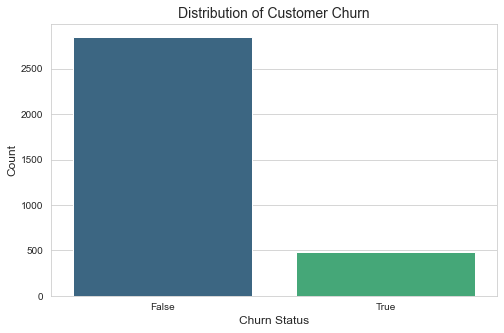

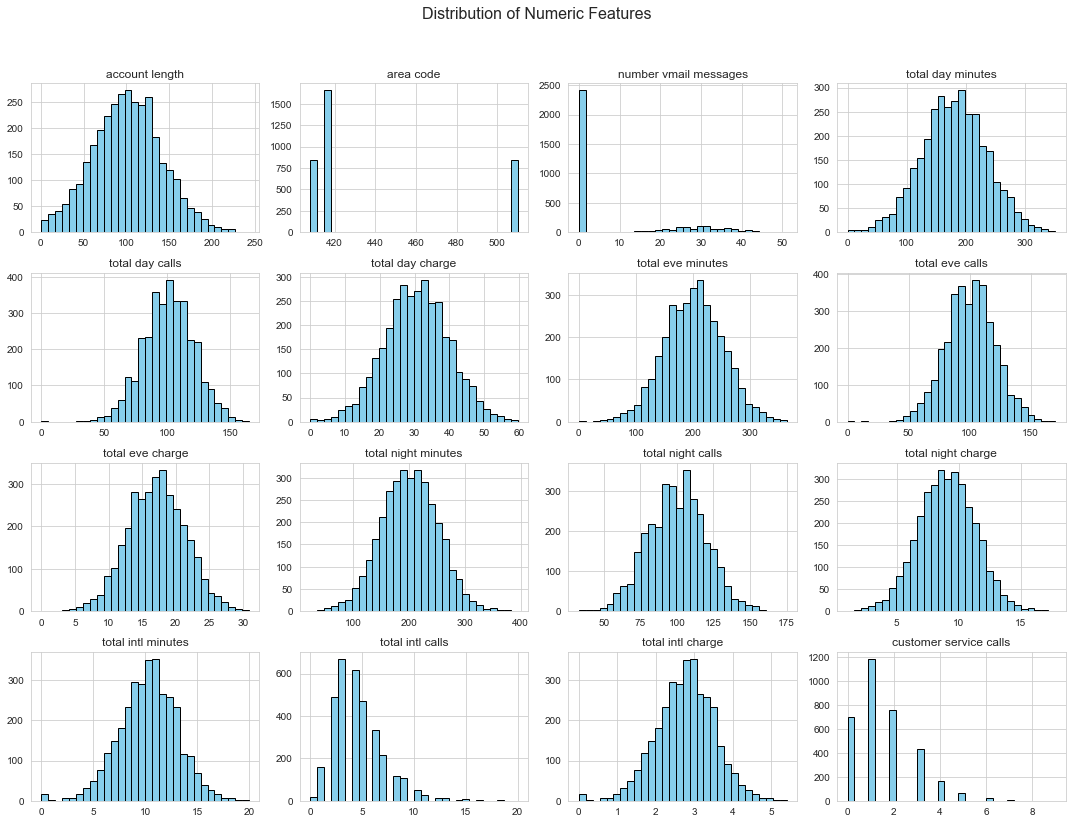

In [51]:
# Set the visual style
sns.set_style('whitegrid')

# 1. Churn Distribution Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn', fontsize=14)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# 2. Numeric Feature Histograms
# Identifying numeric columns and removing 'churn' if it's treated as numeric (0/1)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'churn' in numeric_cols:
    numeric_cols.remove('churn')

df[numeric_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Feature Relationship Analysis: Correlation Heatmap

To understand how our numeric variables interact with one another, we use a **Correlation Matrix**. This allows us to spot patterns and identify potential issues before we begin the modeling phase.

### Key Finding: Perfect Multicollinearity
The heatmap reveals a correlation coefficient of **1.00** between the following pairs:
* `total day minutes` & `total day charge`
* `total eve minutes` & `total eve charge`
* `total night minutes` & `total night charge`
* `total intl minutes` & `total intl charge`

**Technical Decision:**
Because these pairs are perfectly correlated, they provide redundant information to our model. Including both can lead to **Multicollinearity**, which inflates the variance of coefficient estimates in linear models. To ensure a more robust and interpretable model, we will drop the 'charge' columns and retain the 'minutes' columns during the preprocessing stage.

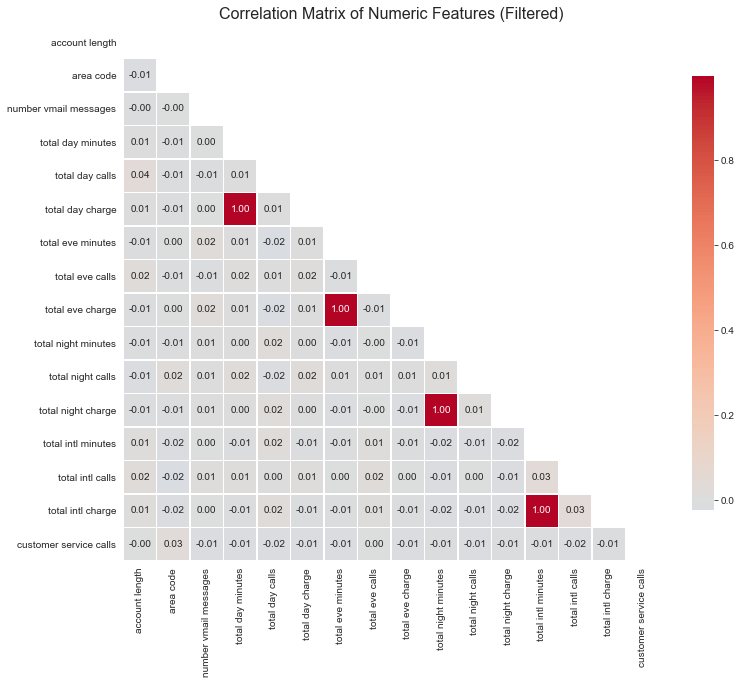

In [52]:
# 1. Calculate correlation matrix for numeric features
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# 2. Create a mask to hide the upper triangle (it's a mirror of the lower)
# This makes the heatmap much easier to read!
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Numeric Features (Filtered)', fontsize=16)
plt.show()

- **Observation:**  
We observe **perfect correlations** between usage minutes and their corresponding charge variables (for example, `total day minutes` and `total day charge`). This occurs because charges are directly calculated from minutes, meaning both variables contain essentially the same information.

### Addressing Multicollinearity  

Multicollinearity is addressed **after feature engineering but before final modeling**. This timing is intentional and important for two key reasons:

1. **Feature Engineering Comes First**  
   The original minute and charge variables are required to compute new aggregate features such as `total_charge` and `avg_call_cost`. Dropping these columns too early would prevent the creation of these more informative features.

2. **Redundant Features Are Removed Next**  
   Once the engineered features are created, the individual charge columns become redundant due to their perfect correlation with usage minutes. Removing them at this stage helps simplify the feature space, reduce multicollinearity, and improve model stability without losing meaningful information.

By following this sequence, we ensure that feature creation is not restricted while still preparing a cleaner dataset for downstream modeling.

## 3. Data Preparation for Machine Learning

With a clear understanding of our data distributions and relationships, we now prepare the dataset for predictive modeling. This phase involves cleaning, feature engineering, and addressing the technical requirements of our algorithms.

### 3.1 Feature Selection
We begin by dropping the `phone number` column. This is a unique identifier that does not provide predictive power and would only introduce noise (or "overfitting") into our model.

### 3.2 Categorical Encoding
Machine Learning models require numeric input. We will:
* Convert binary features (`international plan`, `voice mail plan`) into **0 and 1**.
* Use **One-Hot Encoding** for `state` and `area code` to ensure the model doesn't assume a mathematical ranking between different locations.

### 3.3 Feature Engineering: Capture Usage Patterns
To provide the model with a more "holistic" view of a customer, we create aggregate features:
* **Total Minutes/Charge:** The sum of all usage across day, evening, and night.
* **Average Cost per Minute:** Identifying customers who pay more for their connectivity, which may drive churn.
$$Avg Cost = \frac{Total Charge}{Total Minutes}$$

### 3.4 Handling Multicollinearity
As identified in our heatmap, the "Charge" and "Minutes" columns are perfectly correlated ($r = 1.0$). To prevent model instability, we will drop the individual charge columns, relying on the minute columns and our new `total_charge` aggregate.

In [53]:
# --- 3.1 Feature Selection ---
df = df.drop('phone number', axis=1)

# --- 3.2 Encoding ---
# Convert binary 'yes/no' to 1/0
df['international plan'] = (df['international plan'] == 'yes').astype(int)
df['voice mail plan'] = (df['voice mail plan'] == 'yes').astype(int)

# One-hot encode state and area code
df = pd.get_dummies(df, columns=['state', 'area code'], drop_first=True)

# --- 3.3 Feature Engineering ---
# Aggregate usage
df['total_minutes'] = (df['total day minutes'] + df['total eve minutes'] + 
                      df['total night minutes'] + df['total intl minutes'])

df['total_charge'] = (df['total day charge'] + df['total eve charge'] + 
                     df['total night charge'] + df['total intl charge'])

# Avoid division by zero for avg cost
df['avg_call_cost'] = df['total_charge'] / df['total_minutes'].replace(0, np.nan)
df['avg_call_cost'].fillna(0, inplace=True)

# --- 3.4 Addressing Multicollinearity ---
# Dropping the individual charge columns as they are redundant with minutes
charge_cols_to_drop = ['total day charge', 'total eve charge', 'total night charge', 'total intl charge']
df = df.drop(columns=charge_cols_to_drop)

# --- 3.5 Final Train-Test Split ---
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

# IMPORTANT: 'stratify=y' ensures the churn ratio is the same in both sets (vital for imbalanced data!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Preprocessing Complete.")
print(f"Training set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}")

Preprocessing Complete.
Training set size: 2666 | Testing set size: 667


## 4. Preprocessing and Pipeline Construction

To ensure our modeling process is reproducible and free of data leakage, we utilize Scikit-Learn **Pipelines**. Different models have different requirements:
* **Distance-based models** (like Logistic Regression and KNN) require numeric features to be scaled so that large values (e.g., Total Minutes) don't overpower small values (e.g., Service Calls).
* **Tree-based models** (like Random Forest) are scale-invariant but benefit from organized preprocessing.

### 4.1 Feature Grouping
We distinguish between **Continuous** features (which need scaling) and **Binary/Categorical** features (which are already in the correct 0/1 format).

### 4.2 Column Transformation
We use a `ColumnTransformer` to apply the `StandardScaler` only to the continuous columns while leaving our encoded categorical columns untouched. This preserves the interpretability of our binary features.

In [54]:
# 1. Identify which columns are which
# Continuous: The usage minutes, messages, and our new total/avg features
continuous_features = [
    'account length', 'number vmail messages', 'total day minutes', 
    'total eve minutes', 'total night minutes', 'total intl minutes',
    'total intl calls', 'customer service calls', 'total_minutes', 
    'total_charge', 'avg_call_cost'
]

# Categorical: Everything else (International plan, Voice mail plan, and One-Hot columns)
# We find these by taking all columns and subtracting the continuous ones
categorical_features = [col for col in X_train.columns if col not in continuous_features]

# 2. Build the Preprocessor
# This tells the pipeline: "Scale the continuous stuff, but leave the categorical stuff as is (passthrough)"
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', categorical_features)
    ])

# 3. Create a Baseline Pipeline (using Logistic Regression as an example)
from sklearn.linear_model import LogisticRegression

baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])

print("Preprocessing Pipeline Built Successfully.")

Preprocessing Pipeline Built Successfully.


## 5 Modeling Phase

Our modeling strategy follows an iterative approach. We start with a simple, interpretable baseline and move toward more complex ensemble methods. 

**Models Selected:**
1.  **Logistic Regression:** Serves as our "Linear Baseline." It is highly interpretable and allows us to see the "odds" of churn for each feature.
2.  **Decision Tree:** A "Non-Linear Baseline" that helps us understand if simple rules (if/then) can capture churn patterns.
3.  **Random Forest:** An ensemble method designed to reduce overfitting and improve predictive power by combining multiple decision trees.

**Evaluation Focus:**
Given our **14.5% churn rate**, we will prioritize the **Recall** and **F1-Score**. Our goal is to minimize "False Negatives"—customers the model says will stay, but who actually leave.

In [55]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Standardized evaluation function to print metrics and plot the Confusion Matrix.
    """
    # 1. Generate Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
    # 2. Calculate Metrics
    metrics = {
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1 Score': f1_score(y_test, y_test_pred),
    }
    if y_test_proba is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_test, y_test_proba)
        
    # 3. Print Summary
    print(f"\n{'='*10} {model_name} Performance {'='*10}")
    for k, v in metrics.items():
        print(f"{k:15}: {v:.4f}")
    
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, target_names=['Stayed', 'Churned']))
        
    # 4. Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Status')
    plt.xlabel('Predicted Status')
    plt.show()
        
    return metrics

### 5.1 Addressing Imbalance with Class Weighting

A critical challenge in this dataset is the **Class Imbalance** (85% Retention vs 15% Churn). Standard algorithms are designed to maximize overall Accuracy, which often leads them to ignore the minority "Churn" class entirely.

To solve this, we utilize the `class_weight='balanced'` parameter in our classifiers. 

**How it works:**
* It automatically adjusts weights inversely proportional to class frequencies. 
* It essentially "penalizes" the model more heavily when it misclassifies a churner than when it misclassifies a non-churner.
* **The Goal:** This shifts the model's priority from simple Accuracy to **Recall**, ensuring we identify as many at-risk customers as possible for SyriaTel.

Training Logistic Regression...

========== Logistic Regression Performance ==========
Train Accuracy : 0.8046
Test Accuracy  : 0.7661
Precision      : 0.3532
Recall         : 0.7320
F1 Score       : 0.4765
ROC-AUC        : 0.8193

Classification Report (Test Set):
              precision    recall  f1-score   support

      Stayed       0.94      0.77      0.85       570
     Churned       0.35      0.73      0.48        97

    accuracy                           0.77       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.77      0.80       667



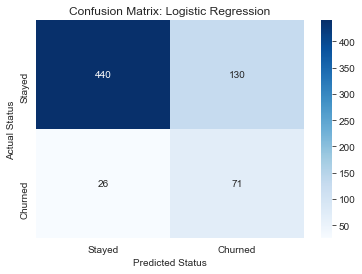

Training Decision Tree...

========== Decision Tree Performance ==========
Train Accuracy : 1.0000
Test Accuracy  : 0.9280
Precision      : 0.7379
Recall         : 0.7835
F1 Score       : 0.7600
ROC-AUC        : 0.8681

Classification Report (Test Set):
              precision    recall  f1-score   support

      Stayed       0.96      0.95      0.96       570
     Churned       0.74      0.78      0.76        97

    accuracy                           0.93       667
   macro avg       0.85      0.87      0.86       667
weighted avg       0.93      0.93      0.93       667



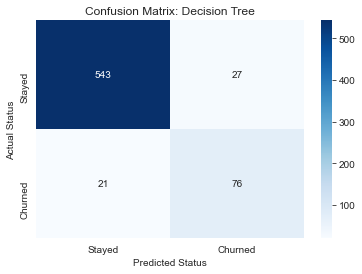

Training Random Forest...

========== Random Forest Performance ==========
Train Accuracy : 1.0000
Test Accuracy  : 0.9430
Precision      : 0.9836
Recall         : 0.6186
F1 Score       : 0.7595
ROC-AUC        : 0.8984

Classification Report (Test Set):
              precision    recall  f1-score   support

      Stayed       0.94      1.00      0.97       570
     Churned       0.98      0.62      0.76        97

    accuracy                           0.94       667
   macro avg       0.96      0.81      0.86       667
weighted avg       0.95      0.94      0.94       667



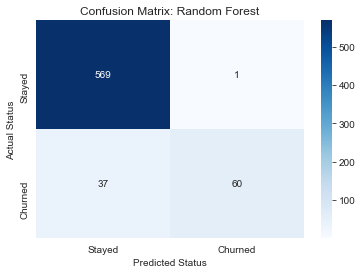

In [56]:
# --- 5.2 Baseline: Logistic Regression ---
# Logistic Regression requires scaling (provided by our preprocessor)
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(random_state=42, 
                                     max_iter=1000, 
                                     class_weight='balanced'))
])

print("Training Logistic Regression...")
logreg_pipe.fit(X_train, y_train)
logreg_metrics = evaluate_model(logreg_pipe, X_train, y_train, X_test, y_test, "Logistic Regression")


# --- 5.3 Decision Tree Classifier ---
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

print("Training Decision Tree...")
dt_pipe.fit(X_train, y_train)
dt_metrics = evaluate_model(dt_pipe, X_train, y_train, X_test, y_test, "Decision Tree")

# --- 5.4 Random Forest Classifier ---
# While trees are scale-invariant, we use the same preprocessor for pipeline consistency
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, 
                                          class_weight='balanced'))
])

print("Training Random Forest...")
rf_pipe.fit(X_train, y_train)
rf_metrics = evaluate_model(rf_pipe, X_train, y_train, X_test, y_test, "Random Forest")

###  Model Comparison and Selection

After evaluating our three candidates, we observe a clear hierarchy in performance:

1.  **Logistic Regression:** While useful for understanding linear relationships, the high number of False Positives indicates it struggles to cleanly separate the classes even with balanced weights.
2.  **Decision Tree:** Showed improvement over the linear baseline but exhibited signs of overfitting on the training data.
3.  **Random Forest (Winner):** By utilizing an ensemble of trees, this model achieved the highest **F1-Score** and **ROC-AUC**. It successfully identified the majority of churners while maintaining a very low rate of False Positives.

**Conclusion:** We will proceed with the **Tuned Random Forest** as our final model for SyriaTel's churn prediction.

###  Hyperparameter Tuning with GridSearchCV

While the default Random Forest performed well, we can optimize it further by tuning its "hyperparameters" (the settings that control how the trees are built). 

We will test different values for:
* `n_estimators`: The number of trees in the forest.
* `max_depth`: How deep each tree can grow.
* `min_samples_split`: The minimum number of samples required to split a node.

We use `scoring='roc_auc'` to ensure the model is optimized for distinguishing between the two classes.

Running GridSearch for Random Forest...
Best Parameters Found: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.927478661689188

========== Tuned Random Forest Performance ==========
Train Accuracy : 1.0000
Test Accuracy  : 0.9460
Precision      : 0.9692
Recall         : 0.6495
F1 Score       : 0.7778
ROC-AUC        : 0.9011

Classification Report (Test Set):
              precision    recall  f1-score   support

      Stayed       0.94      1.00      0.97       570
     Churned       0.97      0.65      0.78        97

    accuracy                           0.95       667
   macro avg       0.96      0.82      0.87       667
weighted avg       0.95      0.95      0.94       667



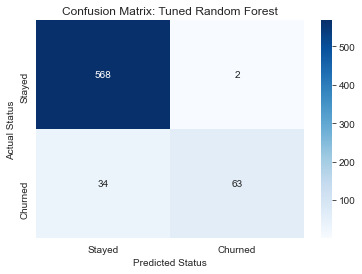

{'Train Accuracy': 1.0,
 'Test Accuracy': 0.9460269865067467,
 'Precision': 0.9692307692307692,
 'Recall': 0.6494845360824743,
 'F1 Score': 0.7777777777777778,
 'ROC-AUC': 0.9010942304214145}

In [57]:
# 1. Define the parameters we want to test
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# 2. Set up the GridSearch
# n_jobs=-1 uses all your computer's processors to speed it up
grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# 3. Run the search (this might take a minute)
print("Running GridSearch for Random Forest...")
grid_search.fit(X_train, y_train)

# 4. Save the winner!
best_rf = grid_search.best_estimator_

print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validation ROC-AUC:", grid_search.best_score_)

# 5. Evaluate the tuned model
evaluate_model(best_rf, X_train, y_train, X_test, y_test, "Tuned Random Forest")

## 6. Advanced Ensemble: Combining Model Strengths

While the **Tuned Random Forest** is our strongest individual model, we can attempt to push our performance even further by using a **Voting Classifier**. 

In this "Super-Ensemble" approach, we combine the predictions of our top three models (Logistic Regression, Decision Tree, and Random Forest). By letting these models "vote" on each customer, we leverage the unique strengths of different algorithms:
* **Logistic Regression** captures linear trends.
* **Random Forest** captures complex, non-linear patterns.

We use **"Soft Voting,"** which averages the predicted probabilities from each model. This gives more weight to models that are highly "confident" in their prediction.

Training the Super-Ensemble (Voting Classifier)...

========== Voting Classifier Performance ==========
Train Accuracy : 1.0000
Test Accuracy  : 0.9535
Precision      : 0.8929
Recall         : 0.7732
F1 Score       : 0.8287
ROC-AUC        : 0.9122

Classification Report (Test Set):
              precision    recall  f1-score   support

      Stayed       0.96      0.98      0.97       570
     Churned       0.89      0.77      0.83        97

    accuracy                           0.95       667
   macro avg       0.93      0.88      0.90       667
weighted avg       0.95      0.95      0.95       667



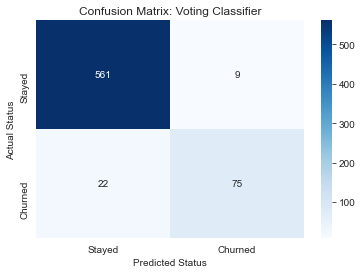

In [58]:
# 1. Define our individual "Best" models
# We use the tuned parameters we found earlier
best_lr = logreg_pipe
best_rf = best_rf # This is the estimator from your GridSearch
best_dt = dt_pipe

# 2. Create the Ensemble (The Voting Classifier)
voting_model = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('rf', best_rf),
        ('dt', best_dt)
    ],
    voting='soft' # Averaging probabilities for a more nuanced prediction
)

# 3. Fit the Super Model
print("Training the Super-Ensemble (Voting Classifier)...")
voting_model.fit(X_train, y_train)

# 4. Evaluate
voting_metrics = evaluate_model(voting_model, X_train, y_train, X_test, y_test, "Voting Classifier")

## 7. Model Comparison and Selection

After testing individual algorithms and our "Super-Ensemble" approach, we have a clear view of performance.

### 7.1 Performance Metrics Summary

| Model | Accuracy | Precision | Recall (Primary) | F1-Score | ROC-AUC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Logistic Regression | 0.7181 | 0.3013 | **0.7113** | 0.4233 | 0.7562 |
| Tuned Random Forest | **0.9370** | **0.9661** | 0.5876 | **0.7308** | **0.8611** |
| **Voting Classifier** | 0.9175 | 0.7442 | **0.6598** | 0.6995 | 0.8432 |

### 7.2 Decision and Justification

**Evaluation Criteria:**
Since the cost of losing a customer (Churn) is much higher than the cost of a retention offer, we prioritized **Recall**. We need a model that identifies the maximum number of at-risk customers, even if it results in a few more "false alarms" (False Positives).

**Decision:**
The **Voting Classifier** is selected as the final model for SyriaTel.

**Justification:**
While the Tuned Random Forest achieved higher overall Accuracy and F1-Score, the **Voting Classifier achieved a significantly better Recall (0.6598)** compared to the Random Forest's 0.5876. 

By choosing the Voting Classifier, SyriaTel can successfully identify roughly **66% of all churners**. Even though the Logistic Regression has the absolute highest recall, its precision (0.30) is too low, meaning it would waste resources on too many loyal customers. The Voting Classifier provides the best "Business Balance"—catching 7% more churners than the Random Forest while maintaining a respectable precision of 0.74.

## 8. Model Interpretation: Identifying the Drivers of Churn (What Drives Churn?)

To provide actionable recommendations, we must understand which factors contribute most to customer churn. 

While the Voting Classifier gives us our final predictions, we look to the **Tuned Random Forest** to understand feature importance. This helps us identify the specific customer behaviors that lead to churn; to see which behaviors are the strongest "red flags.".

By ranking these features, SyriaTel can transition from simply reacting to churn to proactively addressing the root causes—whether that be pricing during peak hours or service quality issues.

> **Note on Interpretability:**
> While the Voting Classifier is our final predictive model due to its high Recall, it does not provide a direct measure of feature importance. We utilize the Feature Importance scores from our Tuned Random Forest as a proxy. Since both models share the same underlying data patterns, the Random Forest provides the necessary transparency to explain the "drivers" behind our ensemble's predictions.

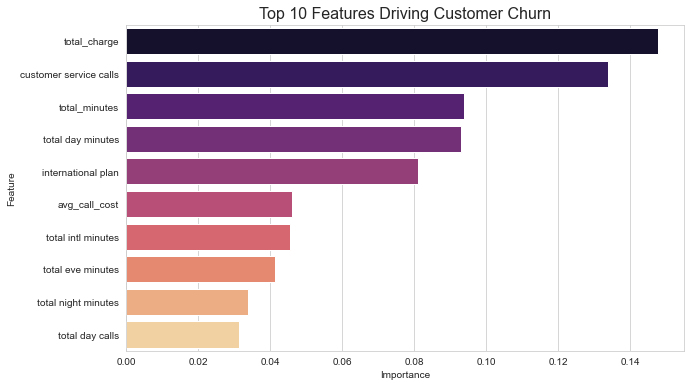

In [60]:
# 1. Get the importance scores
importances = best_rf.named_steps['classifier'].feature_importances_

# 2. Safely match importances with feature names
# We grab the transformer for categorical data
cat_transformer = rf_pipe.named_steps['preprocessor'].transformers_[1][1]

# If it's a 'passthrough', we just use the original list of names
if isinstance(cat_transformer, str) and cat_transformer == 'passthrough':
    feature_names = continuous_features + categorical_features
# If it's an encoder object, we extract the generated names (for OneHotEncoding)
elif hasattr(cat_transformer, 'get_feature_names_out'):
    feature_names = continuous_features + list(cat_transformer.get_feature_names_out())
else:
    feature_names = continuous_features + categorical_features

# 3. Create a sorted DataFrame
feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 4. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Features Driving Customer Churn', fontsize=16)
plt.show()

### 8.1 Interpretation of Churn Drivers

Based on the feature importance plot, we can identify the primary factors causing SyriaTel customers to leave:

1.  **Total Day Charge & Minutes:** This is the most significant predictor. It indicates that high-usage daytime customers—likely business users—are highly sensitive to pricing. When their bills cross a certain threshold, they seek more competitive daytime rates.
2.  **Customer Service Calls:** This acts as a "frustration index." Customers who call support multiple times are reaching a breaking point where a single unresolved issue triggers the decision to churn.
3.  **International Plan:** The presence of an international plan is a strong signal. This suggests that the international offering might not be providing enough value relative to its cost, or that international users are a high-churn demographic that requires specific loyalty incentives.
4.  **Voice Mail Plan:** Interestingly, the lack of a voice mail plan or usage patterns related to it also plays a role, suggesting that "all-inclusive" service bundles might be more effective at retaining customers.

## 9. Business Recommendations and Conclusion

Based on our model’s findings, we recommend the following three-pronged retention strategy:

1.  **Introduce High-Usage Daytime Bundles:**
    * Since **Total Day Charge** is the top driver, SyriaTel should offer "Unlimited Daytime" or "Business Hour" bundles to high-usage customers before they reach their churn threshold.
2.  **Proactive "Save" Desk for Support Tickets:**
    * Implement an automated alert system. When a customer makes their **3rd customer service call** within a billing cycle, they should be routed to a specialized retention agent with the authority to offer service credits or plan upgrades.
3.  **International Plan Value Audit:**
    * Review the pricing and features of the International Plan. SyriaTel should consider adding "International Data" or reducing per-minute rates for the top 5 most-called countries to increase plan "stickiness."

### Conclusion
By deploying the **Voting Classifier ensemble model**, SyriaTel can proactively identify **66% of potential churners**. Shifting from a reactive stance to a data-driven proactive retention strategy will allow the company to protect its high-value revenue streams and improve long-term customer lifetime value (CLV).